# 1. Configuración Inicial y Librerías
En esta sección importamos las herramientas matemáticas necesarias (NumPy, Pandas, Scikit-Learn) y las librerías gráficas (Matplotlib). También conectamos el entorno con Google Drive para poder acceder a los datasets alojados en la nube.

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Carga Automática de Datasets
Como estamos trabajando con el dataset "Quick, Draw!" de Google, tenemos los datos divididos en archivos binarios de formato NumPy (`.npy`). Este bloque busca y carga automáticamente las categorías disponibles (Gatos, Relojes, Autos, Manzanas) convirtiéndolas en variables accesibles.

In [ ]:
directorio = '/content/drive/MyDrive/Colab Notebooks/machine learning/datasets/'
archivos_npy = [f for f in os.listdir(directorio) if f.endswith('.npy')]

for nombre_archivo in archivos_npy:
    nombre_variable = nombre_archivo.replace('.npy', '')
    ruta_completa = os.path.join(directorio, nombre_archivo)
    globals()[nombre_variable] = np.load(ruta_completa)

print(f"Archivos cargados con éxito: {archivos_npy}")
try:
    print(f"Dimensiones del archivo 'cat': {cat.shape}")
except NameError:
    pass

Archivos cargados con éxito: ['apple.npy', 'clock.npy', 'cat.npy', 'car.npy']
Dimensiones del archivo 'cat': (123202, 784)


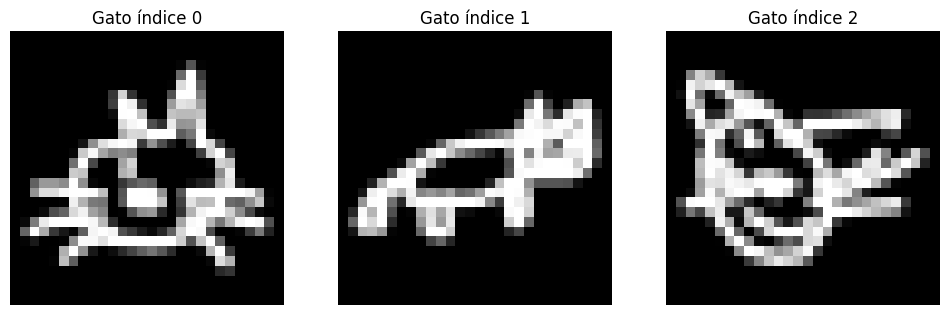

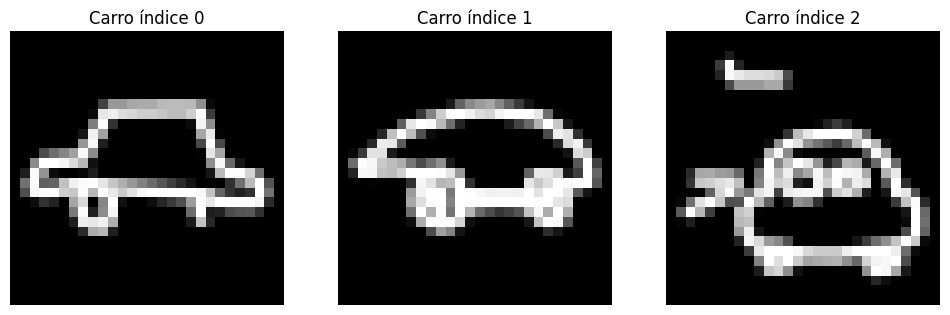

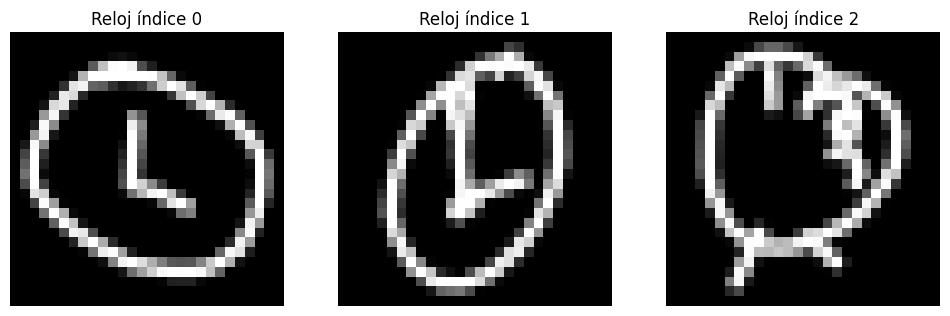

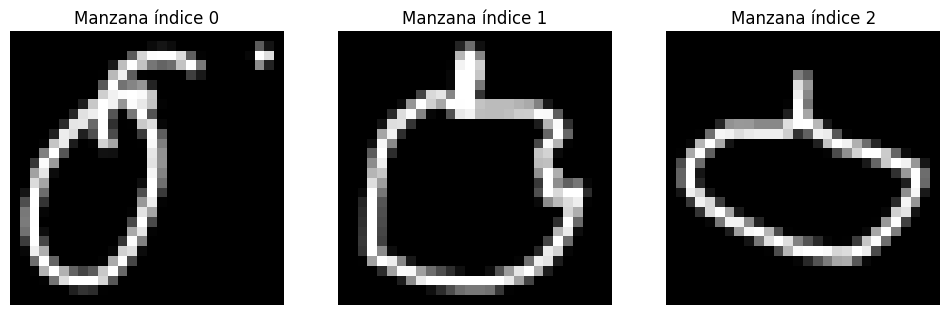

In [ ]:
plt.figure(figsize=(12, 4))

# Recorremos los primeros 3 elementos (índices 0, 1, 2)
for i in range(3):
    plt.subplot(1, 3, i + 1)

    # Seleccionar, redimensionar y mostrar
    dibujo = cat[i].reshape(28, 28)
    plt.imshow(dibujo, cmap='gray')

    plt.title(f"Gato índice {i}")
    plt.axis('off')

plt.show()
plt.figure(figsize=(12, 4))

# Recorremos los primeros 3 elementos (índices 0, 1, 2)
for i in range(3):
    plt.subplot(1, 3, i + 1)

    # Seleccionar, redimensionar y mostrar
    dibujo = car[i].reshape(28, 28)
    plt.imshow(dibujo, cmap='gray')

    plt.title(f"Carro índice {i}")
    plt.axis('off')

plt.show()
plt.figure(figsize=(12, 4))

# Recorremos los primeros 3 elementos (índices 0, 1, 2)
for i in range(3):
    plt.subplot(1, 3, i + 1)

    # Seleccionar, redimensionar y mostrar
    dibujo = clock[i].reshape(28, 28)
    plt.imshow(dibujo, cmap='gray')

    plt.title(f"Reloj índice {i}")
    plt.axis('off')

plt.show()
plt.figure(figsize=(12, 4))

# Recorremos los primeros 3 elementos (índices 0, 1, 2)
for i in range(3):
    plt.subplot(1, 3, i + 1)

    # Seleccionar, redimensionar y mostrar
    dibujo = apple[i].reshape(28, 28)
    plt.imshow(dibujo, cmap='gray')

    plt.title(f"Manzana índice {i}")
    plt.axis('off')

plt.show()

# 3. Preprocesamiento y División de Datos
Para cumplir con los requisitos del laboratorio:
1. **Balanceo:** Seleccionamos exactamente 15,000 ejemplos de cada clase.
2. **Pandas:** Estructuramos los datos en un DataFrame y asignamos las etiquetas $Y$ (0=Manzana, 1=Auto, 2=Reloj, 3=Gato).
3. **Normalización:** Escalamos los píxeles dividiendo entre 255.
4. **Train/Test Split:** Separamos el dataset: 80% para entrenar el modelo y 20% reservado estrictamente para validarlo.

In [ ]:
n = 15000

df_apple = pd.DataFrame(apple[:n])
df_apple['Y'] = 0
df_car = pd.DataFrame(car[:n])
df_car['Y'] = 1
df_clock = pd.DataFrame(clock[:n])
df_clock['Y'] = 2
df_cat = pd.DataFrame(cat[:n])
df_cat['Y'] = 3

df_final = pd.concat([df_apple, df_car, df_clock, df_cat], ignore_index=True)

X = df_final.drop('Y', axis=1).values
y = df_final['Y'].values

X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Datos de entrenamiento (80%): {X_train.shape[0]} ejemplos")
print(f"Datos de prueba (20%): {X_test.shape[0]} ejemplos")

Datos de entrenamiento (80%): 48000 ejemplos
Datos de prueba (20%): 12000 ejemplos


# 4. Funciones Matemáticas: Sigmoide y Costo
Definimos las funciones base para nuestro modelo de Regresión Logística Multiclase. La función `lrCostFunction` implementa de forma vectorizada el cálculo del costo regularizado ($J$) y el gradiente para optimizar los parámetros $\theta$.

In [ ]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def lrCostFunction(theta, X, y, lambda_):
    m = y.size
    if y.dtype == bool:
        y = y.astype(int)

    h = sigmoid(X.dot(theta.T))
    temp = theta.copy()
    temp[0] = 0

    epsilon = 1e-15
    J = (1 / m) * np.sum(-y.dot(np.log(h + epsilon)) - (1 - y).dot(np.log(1 - h + epsilon))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    grad = (1 / m) * (h - y).dot(X)
    grad = grad + (lambda_ / m) * temp

    return J, grad

# 5. Entrenamiento One-vs-All y Extracción de Historial
Implementamos la estrategia "Uno contra Todos". Iteramos por cada una de nuestras 4 clases y utilizamos el optimizador `optimize.minimize` de SciPy. Mediante una función `callback`, capturamos el costo en cada iteración interna para poder graficar la convergencia del modelo posteriormente.

In [ ]:
def oneVsAll_con_historial(X, y, num_labels, lambda_):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    historial_costos = {c: [] for c in range(num_labels)}

    for c in range(num_labels):
        initial_theta = np.zeros(n + 1)

        def guardar_costo(theta_actual):
            costo, _ = lrCostFunction(theta_actual, X, (y == c), lambda_)
            historial_costos[c].append(costo)

        options = {'maxiter': 50}
        res = optimize.minimize(lrCostFunction,
                                initial_theta,
                                (X, (y == c), lambda_),
                                jac=True,
                                method='CG',
                                callback=guardar_costo,
                                options=options)

        all_theta[c] = res.x

    return all_theta, historial_costos

lambda_ = 0.1
num_labels = 4
all_theta, historial = oneVsAll_con_historial(X_train, y_train, num_labels, lambda_)

# 6. Evaluación del Modelo y Gráfica de Costo
Analizamos el rendimiento del modelo aplicando los parámetros aprendidos (`all_theta`) sobre el conjunto de prueba (datos jamás vistos por la IA). También dibujamos la gráfica de costo ($J$) respecto a las iteraciones para garantizar que el algoritmo convergió correctamente.

Efectividad del modelo (Accuracy en conjunto de prueba): 92.31%


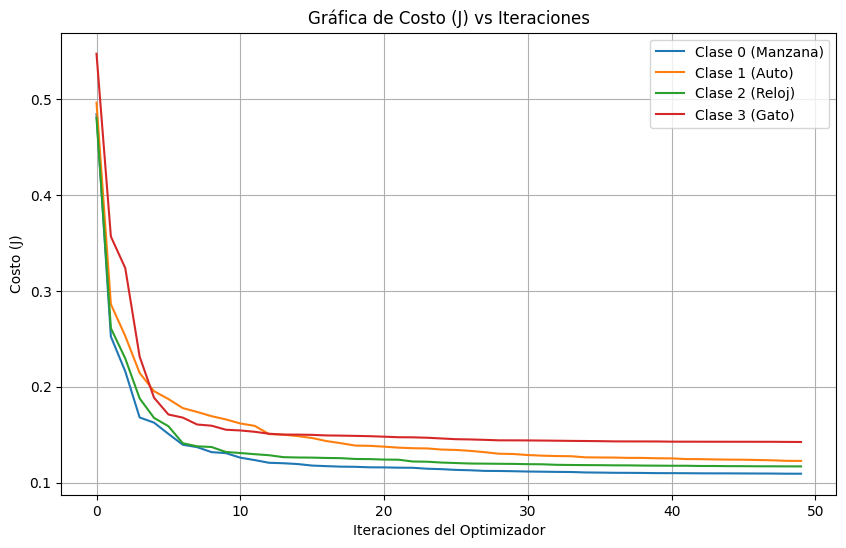

In [ ]:
def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis = 1)
    return p

predicciones = predictOneVsAll(all_theta, X_test)
precision = np.mean(predicciones == y_test) * 100
print(f"Efectividad del modelo (Accuracy en conjunto de prueba): {precision:.2f}%")

plt.figure(figsize=(10, 6))
nombres_clases = ['Manzana', 'Auto', 'Reloj', 'Gato']

for c in range(num_labels):
    plt.plot(historial[c], label=f'Clase {c} ({nombres_clases[c]})')

plt.title('Gráfica de Costo (J) vs Iteraciones')
plt.xlabel('Iteraciones del Optimizador')
plt.ylabel('Costo (J)')
plt.legend()
plt.grid(True)
plt.show()

# 7. Inferencia: Poniendo a Prueba la IA (Demo)
Este bloque toma una imagen completamente al azar del conjunto de validación, la reconstruye en su formato original de 28x28 píxeles para mostrarla en pantalla, y le pide a nuestro modelo entrenado que la clasifique.

In [1]:
indice_azar = random.randint(0, len(X_test) - 1)
imagen_prueba = X_test[indice_azar]
etiqueta_real = y_test[indice_azar]

imagen_formateada = imagen_prueba.reshape(1, -1)

prediccion_numerica = predictOneVsAll(all_theta, imagen_formateada)[0]
prediccion_texto = nombres_clases[prediccion_numerica]
real_texto = nombres_clases[etiqueta_real]

plt.figure(figsize=(4, 4))
plt.imshow(imagen_prueba.reshape(28, 28), cmap='gray')
plt.axis('off')

color_titulo = 'green' if prediccion_numerica == etiqueta_real else 'red'
plt.title(f"Predicción IA: {prediccion_texto}\nClase Real: {real_texto}", color=color_titulo, fontsize=12)
plt.show()

NameError: name 'random' is not defined